# Gravity of a Thick Spherical Shell

This notebook visualizes the gravitational field of a uniform thick spherical shell and compares it with a non-spherical mass distribution having the same total mass. We use dimensionless units with $G=M=R_o=1$, where $R_o$ is the outer radius of the shell. The plotted field is the gravitational acceleration $\vec{g}$; the force on a test mass is $\vec{F}=m\vec{g}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path

G = 1.0
M = 1.0
R_inner = 0.55
R_outer = 1.0
g_surface = G * M / R_outer**2

def enclosed_fraction(r):
    r = np.asarray(r, dtype=float)
    fraction = np.zeros_like(r)
    in_shell = (r >= R_inner) & (r <= R_outer)
    fraction[in_shell] = (r[in_shell]**3 - R_inner**3) / (R_outer**3 - R_inner**3)
    fraction[r > R_outer] = 1.0
    return fraction

def shell_acceleration(x, y, mass=M):
    x, y = np.broadcast_arrays(np.asarray(x, dtype=float), np.asarray(y, dtype=float))
    r = np.hypot(x, y)
    gx = np.zeros_like(r)
    gy = np.zeros_like(r)
    nonzero = r > 0
    factor = np.zeros_like(r)
    factor[nonzero] = -G * mass * enclosed_fraction(r[nonzero]) / r[nonzero]**3
    gx[nonzero] = factor[nonzero] * x[nonzero]
    gy[nonzero] = factor[nonzero] * y[nonzero]
    return gx, gy

def figure_directory():
    cwd = Path.cwd()
    if cwd.name == 'introduction':
        result = cwd / 'figures'
    elif cwd.name == '2_potential_fields':
        result = cwd / 'introduction' / 'figures'
    elif (cwd / '2_potential_fields').exists():
        result = cwd / '2_potential_fields' / 'introduction' / 'figures'
    else:
        result = cwd / 'book' / '2_potential_fields' / 'introduction' / 'figures'
    result.mkdir(parents=True, exist_ok=True)
    return result

figure_dir = figure_directory()

## The symmetric shell

Inside the empty cavity, every spherical shell contributes zero field. Within the material, only the mass at smaller radii contributes to the field. Outside the shell, all its mass acts as though it were concentrated at the centre.

In [2]:
fig, (ax_field, ax_profile) = plt.subplots(1, 2, figsize=(11.5, 4.8))

grid = np.linspace(-1.5, 1.5, 15)
X, Y = np.meshgrid(grid, grid)
gx, gy = shell_acceleration(X, Y)
magnitude = np.hypot(gx, gy) / g_surface
quiver = ax_field.quiver(
    X, Y, gx / g_surface, gy / g_surface, magnitude,
    cmap='viridis', norm=Normalize(0, 1.05), scale=6.5, width=0.007
)
theta = np.linspace(0, 2 * np.pi, 500)
ax_field.fill(R_outer * np.cos(theta), R_outer * np.sin(theta), color='#d9d9d9', zorder=-3)
ax_field.fill(R_inner * np.cos(theta), R_inner * np.sin(theta), color='white', zorder=-2)
ax_field.plot(R_inner * np.cos(theta), R_inner * np.sin(theta), color='0.25', lw=1.2)
ax_field.plot(R_outer * np.cos(theta), R_outer * np.sin(theta), color='0.25', lw=1.2)
ax_field.set(xlim=(-1.6, 1.6), ylim=(-1.6, 1.6), xlabel='$x/R_o$', ylabel='$y/R_o$',
             title='Field of a uniform thick shell')
ax_field.set_aspect('equal')
fig.colorbar(quiver, ax=ax_field, label=r'$|\vec{g}|/(GM/R_o^2)$', shrink=0.82)

r = np.linspace(0, 2.2, 900)
g_magnitude = np.zeros_like(r)
nonzero = r > 0
g_magnitude[nonzero] = G * M * enclosed_fraction(r[nonzero]) / r[nonzero]**2
ax_profile.axvspan(0, R_inner, color='#e8f4f8', label='empty cavity')
ax_profile.axvspan(R_inner, R_outer, color='#e0e0e0', label='shell material')
ax_profile.plot(r, g_magnitude / g_surface, color='#b23a48', lw=2.5)
ax_profile.axvline(R_inner, color='0.35', lw=1)
ax_profile.axvline(R_outer, color='0.35', lw=1)
ax_profile.set(xlim=(0, 2.2), ylim=(0, 1.12), xlabel='$r/R_o$',
               ylabel=r'$|\vec{g}|/(GM/R_o^2)$', title='Field magnitude versus radius')
ax_profile.grid(alpha=0.25)
ax_profile.legend(frameon=False, loc='upper right')

fig.tight_layout()
fig.savefig(figure_dir / 'spherical_shell_field.png', dpi=200, bbox_inches='tight')
plt.close(fig)

```{figure} figures/spherical_shell_field.png
:width: 100%

The field of a uniform thick spherical shell and its radial magnitude.
```

## Breaking spherical symmetry

For an intentionally exaggerated disturbance, we leave $0.82M$ in the uniform shell and redistribute the remaining mass into two point-like concentrations, $m_1=0.11M$ and $m_2=0.07M$. The disturbed and uniform models therefore have the same total mass. A small numerical softening is used only to keep the arrows finite close to the plotted point masses. The measurement curves outside the shell use the exact point-mass field.

In [3]:
shell_mass = 0.82 * M
anomalies = [
    (0.11 * M, 0.72, 0.18),
    (0.07 * M, -0.35, -0.68),
]

def disturbed_acceleration(x, y, softened=False):
    gx, gy = shell_acceleration(x, y, mass=shell_mass)
    x, y = np.broadcast_arrays(np.asarray(x, dtype=float), np.asarray(y, dtype=float))
    epsilon2 = 0.07**2 if softened else 0.0
    for point_mass, xp, yp in anomalies:
        dx = x - xp
        dy = y - yp
        distance_squared = dx**2 + dy**2 + epsilon2
        factor = -G * point_mass / distance_squared**1.5
        gx = gx + factor * dx
        gy = gy + factor * dy
    return gx, gy

fig = plt.figure(figsize=(10.5, 9.2), layout='constrained')
grid_spec = fig.add_gridspec(2, 2, height_ratios=(1, 0.72))
axes = [
    fig.add_subplot(grid_spec[0, 0]),
    fig.add_subplot(grid_spec[0, 1]),
    fig.add_subplot(grid_spec[1, :]),
]
plot_models = [
    ('Uniform shell, total mass $M$', lambda x, y: shell_acceleration(x, y, mass=M)),
    ('Same total mass, disturbed', lambda x, y: disturbed_acceleration(x, y, softened=True)),
]

grid = np.linspace(-1.4, 1.4, 15)
X, Y = np.meshgrid(grid, grid)
for ax, (title, field_function) in zip(axes[:2], plot_models):
    gx, gy = field_function(X, Y)
    magnitude = np.hypot(gx, gy) / g_surface
    displayed_magnitude = np.maximum(magnitude, 1e-12)
    clipped_magnitude = np.minimum(displayed_magnitude, 1.4)
    gx_display = gx / displayed_magnitude * clipped_magnitude / g_surface
    gy_display = gy / displayed_magnitude * clipped_magnitude / g_surface
    q = ax.quiver(
        X, Y, gx_display, gy_display, magnitude, cmap='viridis',
        norm=Normalize(0, 1.4), scale=8, width=0.007
    )
    ax.fill(R_outer * np.cos(theta), R_outer * np.sin(theta), color='#d9d9d9', zorder=-3)
    ax.fill(R_inner * np.cos(theta), R_inner * np.sin(theta), color='white', zorder=-2)
    ax.plot(R_inner * np.cos(theta), R_inner * np.sin(theta), color='0.25', lw=1)
    ax.plot(R_outer * np.cos(theta), R_outer * np.sin(theta), color='0.25', lw=1)
    ax.set(xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), xlabel='$x/R_o$', ylabel='$y/R_o$', title=title)
    ax.set_aspect('equal')

for point_mass, xp, yp in anomalies:
    axes[1].scatter(xp, yp, s=700 * point_mass / M, color='#d1495b', edgecolor='white', lw=1.2, zorder=5)
    axes[1].annotate(f'${point_mass/M:.2f}M$', (xp, yp), xytext=(6, 7),
                     textcoords='offset points', fontsize=9, weight='bold')
fig.colorbar(
    q, ax=axes[:2], orientation='horizontal',
    label=r'$|\vec{g}|/(GM/R_o^2)$', shrink=0.72, pad=0.08, aspect=38
)

r_measure = 1.35 * R_outer
angles = np.linspace(0, 2 * np.pi, 500)
xm = r_measure * np.cos(angles)
ym = r_measure * np.sin(angles)
gx_m, gy_m = disturbed_acceleration(xm, ym, softened=False)
radial = gx_m * np.cos(angles) + gy_m * np.sin(angles)
tangential = -gx_m * np.sin(angles) + gy_m * np.cos(angles)
reference = G * M / r_measure**2
angle_degrees = np.rad2deg(angles)
axes[2].axhline(-1, color='0.35', ls='--', label='uniform: radial')
axes[2].axhline(0, color='0.55', ls=':', label='uniform: tangential')
axes[2].plot(angle_degrees, radial / reference, color='#b23a48', lw=2.2, label='disturbed: radial')
axes[2].plot(angle_degrees, tangential / reference, color='#287271', lw=2.2, label='disturbed: tangential')
axes[2].set(xlim=(0, 360), xlabel='measurement angle [degrees]',
            ylabel='field component / $(GM/r_m^2)$',
            title='Measurements at $r_m=1.35R_o$')
axes[2].set_xticks([0, 90, 180, 270, 360])
axes[2].grid(alpha=0.25)
axes[2].legend(frameon=False, fontsize=8, loc='lower right')

fig.savefig(figure_dir / 'spherical_shell_disturbance.png', dpi=200, bbox_inches='tight')
plt.close(fig)

```{figure} figures/spherical_shell_disturbance.png
:width: 100%

The uniform and disturbed fields, followed by measurements around the shell.
```

The uniform field is radial and depends only on distance from the centre. The disturbed field is neither purely radial nor constant around a measurement circle. Its angular variations reveal departures from spherical symmetry. At distances much larger than the source, these variations become weaker and the leading field approaches that of a point mass containing the total mass $M$.

## Explore the mass distribution

Use the controls to change the shell's inner radius and the polar position of each mass concentration. The outer radius and all three mass fractions remain fixed, so every configuration has the same total mass $M$. In the published TeachBook, activate **Live Code** from the rocket menu to enable the controls.

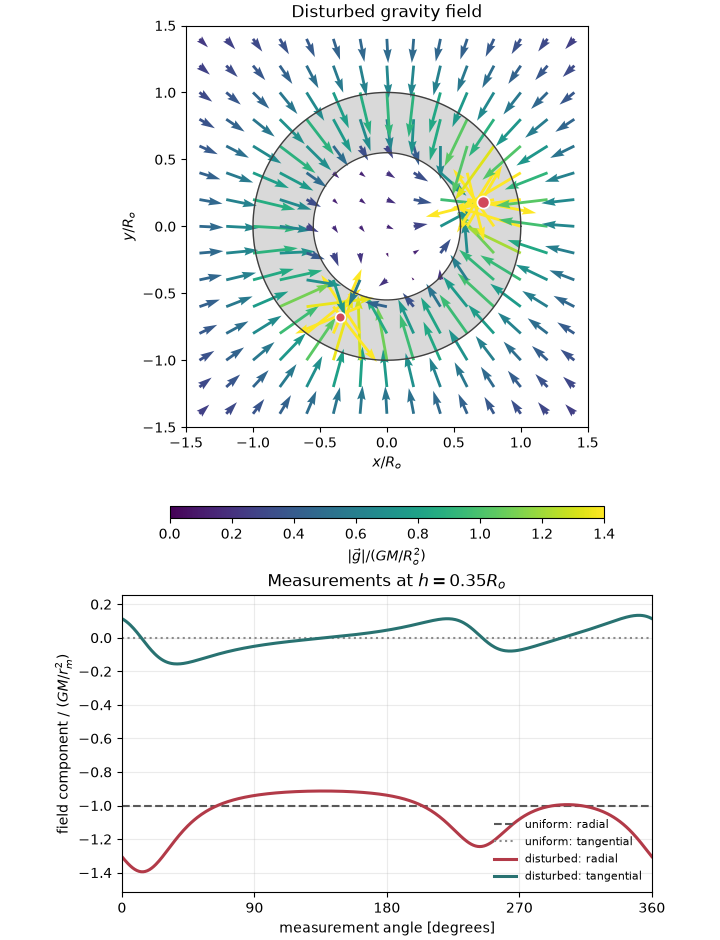

In [4]:
# In TeachBooks, ipympl is installed in the browser-side Python kernel.
try:
    import micropip
except ImportError:
    micropip = None
if micropip is not None:
    await micropip.install('ipympl')

import ipywidgets as widgets
from IPython.display import display
from matplotlib.cm import ScalarMappable

get_ipython().run_line_magic('matplotlib', 'widget')
plt.ioff()

interactive_fig = plt.figure(figsize=(7.2, 9.4), layout='constrained')
interactive_grid = interactive_fig.add_gridspec(
    2, 3, width_ratios=(0.08, 0.84, 0.08), height_ratios=(1.35, 1)
)
interactive_field = interactive_fig.add_subplot(interactive_grid[0, 1])
interactive_measurement = interactive_fig.add_subplot(interactive_grid[1, 1])
interactive_fig.canvas.layout.width = '100%'
interactive_fig.canvas.layout.max_width = '760px'
interactive_fig.canvas.toolbar_visible = False
interactive_fig.canvas.header_visible = False
interactive_fig.canvas.footer_visible = False
interactive_norm = Normalize(0, 1.4)
interactive_fig.colorbar(
    ScalarMappable(norm=interactive_norm, cmap='viridis'),
    ax=interactive_field, orientation='horizontal',
    label=r'$|\vec{g}|/(GM/R_o^2)$', shrink=0.82, pad=0.08, aspect=35
)

control_style = {'description_width': '105px'}
control_layout = widgets.Layout(width='340px')
inner_radius_control = widgets.FloatSlider(
    value=0.55, min=0.15, max=0.80, step=0.05, description='Inner radius',
    readout_format='.2f', continuous_update=False, style=control_style, layout=control_layout
)
radius_1_control = widgets.FloatSlider(
    value=np.hypot(0.72, 0.18), min=0.0, max=1.0, step=0.05, description='Mass 1 radius',
    readout_format='.2f', continuous_update=False, style=control_style, layout=control_layout
)
angle_1_control = widgets.FloatSlider(
    value=np.rad2deg(np.arctan2(0.18, 0.72)), min=0, max=360, step=5, description='Mass 1 angle',
    readout_format='.0f', continuous_update=False, style=control_style, layout=control_layout
)
radius_2_control = widgets.FloatSlider(
    value=np.hypot(-0.35, -0.68), min=0.0, max=1.0, step=0.05, description='Mass 2 radius',
    readout_format='.2f', continuous_update=False, style=control_style, layout=control_layout
)
angle_2_control = widgets.FloatSlider(
    value=np.rad2deg(np.arctan2(-0.68, -0.35)) % 360, min=0, max=360, step=5, description='Mass 2 angle',
    readout_format='.0f', continuous_update=False, style=control_style, layout=control_layout
)
measurement_height_control = widgets.FloatSlider(
    value=0.35, min=0.05, max=1.50, step=0.05, description='Height h/Ro',
    readout_format='.2f', continuous_update=False, style=control_style, layout=control_layout
)

def update_interactive_figure(change=None):
    global R_inner, anomalies
    R_inner = inner_radius_control.value
    angle_1 = np.deg2rad(angle_1_control.value)
    angle_2 = np.deg2rad(angle_2_control.value)
    anomalies = [
        (0.11 * M, radius_1_control.value * np.cos(angle_1), radius_1_control.value * np.sin(angle_1)),
        (0.07 * M, radius_2_control.value * np.cos(angle_2), radius_2_control.value * np.sin(angle_2)),
    ]

    interactive_field.clear()
    gx, gy = disturbed_acceleration(X, Y, softened=True)
    magnitude = np.hypot(gx, gy) / g_surface
    safe_magnitude = np.maximum(magnitude, 1e-12)
    clipped_magnitude = np.minimum(safe_magnitude, 1.4)
    gx_display = gx / safe_magnitude * clipped_magnitude / g_surface
    gy_display = gy / safe_magnitude * clipped_magnitude / g_surface
    interactive_field.quiver(
        X, Y, gx_display, gy_display, magnitude, cmap='viridis',
        norm=interactive_norm, scale=8, width=0.007
    )
    interactive_field.fill(
        R_outer * np.cos(theta), R_outer * np.sin(theta), color='#d9d9d9', zorder=-3
    )
    interactive_field.fill(
        R_inner * np.cos(theta), R_inner * np.sin(theta), color='white', zorder=-2
    )
    interactive_field.plot(R_inner * np.cos(theta), R_inner * np.sin(theta), color='0.25', lw=1)
    interactive_field.plot(R_outer * np.cos(theta), R_outer * np.sin(theta), color='0.25', lw=1)
    for point_mass, xp, yp in anomalies:
        interactive_field.scatter(
            xp, yp, s=700 * point_mass / M, color='#d1495b', edgecolor='white', lw=1.2, zorder=5
        )
    interactive_field.set(
        xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), xlabel='$x/R_o$', ylabel='$y/R_o$',
        title='Disturbed gravity field'
    )
    interactive_field.set_aspect('equal')

    measurement_radius = R_outer + measurement_height_control.value
    xm_interactive = measurement_radius * np.cos(angles)
    ym_interactive = measurement_radius * np.sin(angles)
    measurement_reference = G * M / measurement_radius**2
    gx_m, gy_m = disturbed_acceleration(xm_interactive, ym_interactive, softened=False)
    radial = gx_m * np.cos(angles) + gy_m * np.sin(angles)
    tangential = -gx_m * np.sin(angles) + gy_m * np.cos(angles)
    radial_normalized = radial / measurement_reference
    tangential_normalized = tangential / measurement_reference
    interactive_measurement.clear()
    interactive_measurement.axhline(-1, color='0.35', ls='--', label='uniform: radial')
    interactive_measurement.axhline(0, color='0.55', ls=':', label='uniform: tangential')
    interactive_measurement.plot(
        angle_degrees, radial_normalized, color='#b23a48', lw=2.2, label='disturbed: radial'
    )
    interactive_measurement.plot(
        angle_degrees, tangential_normalized, color='#287271', lw=2.2, label='disturbed: tangential'
    )
    interactive_measurement.set(
        xlim=(0, 360), xlabel='measurement angle [degrees]',
        ylabel='field component / $(GM/r_m^2)$',
        title=fr'Measurements at $h={measurement_height_control.value:.2f}R_o$'
    )
    plotted_values = np.concatenate((radial_normalized, tangential_normalized, [-1, 0]))
    value_span = plotted_values.max() - plotted_values.min()
    margin = max(0.08 * value_span, 0.08)
    interactive_measurement.set_ylim(plotted_values.min() - margin, plotted_values.max() + margin)
    interactive_measurement.set_xticks([0, 90, 180, 270, 360])
    interactive_measurement.grid(alpha=0.25)
    interactive_measurement.legend(frameon=False, fontsize=8, loc='lower right')
    interactive_fig.canvas.draw_idle()

controls = [
    inner_radius_control, radius_1_control, angle_1_control, radius_2_control, angle_2_control,
    measurement_height_control
]
for control in controls:
    control.observe(update_interactive_figure, names='value')

update_interactive_figure()
control_panel = widgets.VBox([
    inner_radius_control, radius_1_control, angle_1_control,
    radius_2_control, angle_2_control, measurement_height_control
])
display(control_panel, interactive_fig.canvas)